# 02 Pix2Pix Training

This notebook trains Pix2Pix directly from notebook cells and saves the same artifacts into `outputs/`.


In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "i2i").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current notebook directory.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

print(f"Repo root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")


Repo root: /home/arderd/gan-lab-task-2
Working directory: /home/arderd/gan-lab-task-2


In [2]:
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [3]:
import gc
import json
import shutil
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image as PILImage
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from i2i.data import PairedImageDataset
from i2i.models import PatchDiscriminator, UNetGenerator
from i2i.train_utils import (
    append_jsonl,
    autocast_context,
    configure_runtime_for_device,
    compute_psnr_batch,
    count_parameters,
    ensure_dir,
    linear_decay_multiplier,
    move_modules_to_device,
    resolve_device,
    save_checkpoint,
    save_triplet_batch,
    set_seed,
)

def is_improved(metric_value: float, best_value: float, mode: str, min_delta: float) -> bool:
    if mode == "min":
        return metric_value < (best_value - min_delta)
    return metric_value > (best_value + min_delta)

@torch.no_grad()
def validate_pix2pix(
    generator: UNetGenerator,
    loader: DataLoader,
    device: torch.device,
    use_channels_last: bool = False,
    max_batches: int | None = None,
    use_amp: bool = False,
) -> tuple[dict[str, float], tuple[torch.Tensor, torch.Tensor, torch.Tensor] | None]:
    generator.eval()
    total_l1 = 0.0
    total_psnr = 0.0
    total_items = 0
    sample_bundle = None

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        real_a = batch["A"].to(device, non_blocking=(device.type == "cuda"))
        real_b = batch["B"].to(device, non_blocking=(device.type == "cuda"))
        if use_channels_last:
            real_a = real_a.contiguous(memory_format=torch.channels_last)
            real_b = real_b.contiguous(memory_format=torch.channels_last)
        with autocast_context(device, enabled=use_amp):
            fake_b = generator(real_a)

        if sample_bundle is None:
            sample_bundle = (real_a.detach().cpu(), fake_b.detach().cpu(), real_b.detach().cpu())

        batch_size = real_a.size(0)
        total_items += batch_size
        total_l1 += float(nn.functional.l1_loss(fake_b, real_b, reduction="mean").item()) * batch_size
        total_psnr += compute_psnr_batch(fake_b, real_b) * batch_size

    if total_items == 0:
        return {"val_l1": 0.0, "val_psnr": 0.0}, sample_bundle
    return {"val_l1": total_l1 / total_items, "val_psnr": total_psnr / total_items}, sample_bundle

def train_pix2pix(
    *,
    data_root: Path,
    in_domain: str,
    out_domain: str,
    save_dir: Path,
    image_size: int,
    epochs: int,
    batch_size: int,
    num_workers: int,
    lr: float,
    beta1: float,
    beta2: float,
    lambda_l1: float,
    decay_start_epoch: int,
    max_val_batches: int | None,
    early_stopping_patience: int,
    early_stopping_metric: str,
    early_stopping_mode: str,
    early_stopping_min_delta: float,
    sample_every: int,
    checkpoint_every: int,
    num_sample_items: int,
    seed: int,
    device_arg: str,
    channels_last: bool = False,
    use_amp: bool | None = None,
    reset_run: bool = False,
) -> dict[str, Any]:
    set_seed(seed)

    # Free stale GPU memory from prior runs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs <= 0:
        raise ValueError("epochs must be > 0")
    if not (0 < decay_start_epoch <= epochs):
        raise ValueError("decay_start_epoch must be in [1, epochs]")
    if early_stopping_patience < 0:
        raise ValueError("early_stopping_patience must be >= 0")
    if early_stopping_min_delta < 0:
        raise ValueError("early_stopping_min_delta must be >= 0")

    if reset_run and save_dir.exists():
        shutil.rmtree(save_dir)

    train_dataset = PairedImageDataset(
        root=data_root,
        split="train",
        in_domain=in_domain,
        out_domain=out_domain,
        image_size=image_size,
        hflip=True,
    )
    val_dataset = PairedImageDataset(
        root=data_root,
        split="val",
        in_domain=in_domain,
        out_domain=out_domain,
        image_size=image_size,
        hflip=False,
    )

    device = resolve_device(device_arg)
    configure_runtime_for_device(device)
    modules, device, used_cpu_fallback = move_modules_to_device(
        {
            "generator": UNetGenerator(),
            "discriminator": PatchDiscriminator(in_channels=6),
        },
        device,
        allow_cpu_fallback=(device_arg.strip().lower() == "auto"),
    )
    generator = modules["generator"]
    discriminator = modules["discriminator"]
    if used_cpu_fallback:
        configure_runtime_for_device(device)
        print("CUDA was out of memory during model initialization. Falling back to CPU because DEVICE='auto'.")

    use_amp = (device.type == "cuda") if use_amp is None else bool(use_amp and device.type == "cuda")
    use_channels_last = channels_last and device.type == "cuda"
    if channels_last and device.type != "cuda":
        print(f"Note: channels_last is only enabled on CUDA. Ignoring it for device={device.type}.")
    print(
        f"Running on device={device}"
        f"{' with channels_last' if use_channels_last else ''} "
        f"{'with AMP ' if use_amp else ''}"
        f"(num_workers={num_workers})"
    )

    loader_kwargs = {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "pin_memory": (device.type == "cuda"),
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)

    if use_channels_last:
        generator = generator.to(memory_format=torch.channels_last)
        discriminator = discriminator.to(memory_format=torch.channels_last)

    criterion_gan = nn.BCEWithLogitsLoss()
    criterion_l1 = nn.L1Loss()

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    lambda_fn = lambda epoch: linear_decay_multiplier(epoch + 1, epochs, decay_start_epoch)
    scheduler_g = torch.optim.lr_scheduler.LambdaLR(optimizer_g, lr_lambda=lambda_fn)
    scheduler_d = torch.optim.lr_scheduler.LambdaLR(optimizer_d, lr_lambda=lambda_fn)

    checkpoints_dir = ensure_dir(save_dir / "checkpoints")
    samples_dir = ensure_dir(save_dir / "samples")
    logs_dir = ensure_dir(save_dir / "logs")
    log_path = logs_dir / "train_log.jsonl"
    if log_path.exists() and reset_run:
        log_path.unlink()

    config = {
        "data_root": str(data_root),
        "in_domain": in_domain,
        "out_domain": out_domain,
        "image_size": image_size,
        "epochs": epochs,
        "batch_size": batch_size,
        "num_workers": num_workers,
        "lr": lr,
        "beta1": beta1,
        "beta2": beta2, # beta1 is typically set to 0.5 instead of the usual 0.9 — intentionally to make training less stable, which helps the GAN not get stuck.
        "lambda_l1": lambda_l1,
        "decay_start_epoch": decay_start_epoch,
        "max_val_batches": max_val_batches,
        "early_stopping_patience": early_stopping_patience,
        "early_stopping_metric": early_stopping_metric,
        "early_stopping_mode": early_stopping_mode,
        "early_stopping_min_delta": early_stopping_min_delta,
        "save_dir": str(save_dir),
        "sample_every": sample_every,
        "checkpoint_every": checkpoint_every,
        "num_sample_items": num_sample_items,
        "seed": seed,
        "device": str(device),
        "channels_last": use_channels_last,
        "use_amp": use_amp,
        "train_pairs": len(train_dataset),
        "val_pairs": len(val_dataset),
        "generator_params": count_parameters(generator),
        "discriminator_params": count_parameters(discriminator),
    }
    with (logs_dir / "config.json").open("w", encoding="utf-8") as config_file:
        json.dump(config, config_file, indent=2)

    best_val_psnr = float("-inf")
    early_enabled = early_stopping_patience > 0
    early_best = float("inf") if early_stopping_mode == "min" else float("-inf")
    early_best_epoch = 0
    bad_epochs = 0
    early_stopped = False
    early_stop_epoch = None
    total_train_start = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        generator.train()
        discriminator.train()

        running_g = 0.0
        running_d = 0.0
        running_gan = 0.0
        running_l1 = 0.0
        num_batches_seen = 0

        progress = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{epochs:03d}", leave=False)
        for batch in progress:
            real_a = batch["A"].to(device, non_blocking=(device.type == "cuda"))
            real_b = batch["B"].to(device, non_blocking=(device.type == "cuda"))
            if use_channels_last:
                real_a = real_a.contiguous(memory_format=torch.channels_last)
                real_b = real_b.contiguous(memory_format=torch.channels_last)

            optimizer_d.zero_grad(set_to_none=True)
            with autocast_context(device, enabled=use_amp):
                fake_b = generator(real_a)
                pred_real = discriminator(torch.cat([real_a, real_b], dim=1))
                pred_fake = discriminator(torch.cat([real_a, fake_b.detach()], dim=1))
                loss_d_real = criterion_gan(pred_real, torch.ones_like(pred_real))
                loss_d_fake = criterion_gan(pred_fake, torch.zeros_like(pred_fake))
                loss_d = 0.5 * (loss_d_real + loss_d_fake)
            scaler.scale(loss_d).backward()
            scaler.step(optimizer_d)

            optimizer_g.zero_grad(set_to_none=True)
            with autocast_context(device, enabled=use_amp):
                pred_fake = discriminator(torch.cat([real_a, fake_b], dim=1))
                loss_g_gan = criterion_gan(pred_fake, torch.ones_like(pred_fake))
                loss_g_l1 = criterion_l1(fake_b, real_b) * lambda_l1
                loss_g = loss_g_gan + loss_g_l1
            scaler.scale(loss_g).backward()
            scaler.step(optimizer_g)
            scaler.update()

            running_g += float(loss_g.item())
            running_d += float(loss_d.item())
            running_gan += float(loss_g_gan.item())
            running_l1 += float(loss_g_l1.item())
            num_batches_seen += 1
            progress.set_postfix(
                {
                    "G": f"{running_g / num_batches_seen:.3f}",
                    "D": f"{running_d / num_batches_seen:.3f}",
                    "L1": f"{running_l1 / num_batches_seen:.3f}",
                }
            )

        val_metrics, sample_bundle = validate_pix2pix(
            generator,
            val_loader,
            device,
            use_channels_last=use_channels_last,
            max_batches=max_val_batches,
            use_amp=use_amp,
        )
        epoch_seconds = time.time() - epoch_start
        scheduler_g.step()
        scheduler_d.step()

        metrics = {
            "epoch": epoch,
            "loss_g": running_g / max(1, num_batches_seen),
            "loss_d": running_d / max(1, num_batches_seen),
            "loss_g_gan": running_gan / max(1, num_batches_seen),
            "loss_g_l1": running_l1 / max(1, num_batches_seen),
            "val_l1": val_metrics["val_l1"],
            "val_psnr": val_metrics["val_psnr"],
            "epoch_seconds": epoch_seconds,
            "lr": optimizer_g.param_groups[0]["lr"],
        }

        if early_enabled:
            if early_stopping_metric not in metrics:
                available = ", ".join(sorted(metrics.keys()))
                raise KeyError(
                    f"Early-stopping metric '{early_stopping_metric}' not found in metrics. Available metrics: {available}"
                )
            metric_value = float(metrics[early_stopping_metric])
            if is_improved(metric_value, early_best, early_stopping_mode, early_stopping_min_delta):
                early_best = metric_value
                early_best_epoch = epoch
                bad_epochs = 0
            else:
                bad_epochs += 1
            metrics["early_stop_metric"] = early_stopping_metric
            metrics["early_stop_metric_value"] = metric_value
            metrics["early_stop_best_value"] = early_best
            metrics["early_stop_best_epoch"] = early_best_epoch
            metrics["early_stop_bad_epochs"] = bad_epochs

        append_jsonl(log_path, metrics)

        if sample_bundle is not None and (epoch % sample_every == 0 or epoch == 1):
            save_triplet_batch(
                real_a=sample_bundle[0],
                fake_b=sample_bundle[1],
                real_b=sample_bundle[2],
                output_path=samples_dir / f"epoch_{epoch:03d}.png",
                max_items=num_sample_items,
            )

        checkpoint_payload = {
            "epoch": epoch,
            "generator_state": generator.state_dict(),
            "discriminator_state": discriminator.state_dict(),
            "optimizer_g_state": optimizer_g.state_dict(),
            "optimizer_d_state": optimizer_d.state_dict(),
            "scheduler_g_state": scheduler_g.state_dict(),
            "scheduler_d_state": scheduler_d.state_dict(),
            "metrics": metrics,
            "config": config,
        }

        if epoch % checkpoint_every == 0 or epoch == epochs:
            save_checkpoint(checkpoint_payload, checkpoints_dir / f"epoch_{epoch:03d}.pt")
        save_checkpoint(checkpoint_payload, checkpoints_dir / "latest.pt")

        if val_metrics["val_psnr"] > best_val_psnr:
            best_val_psnr = val_metrics["val_psnr"]
            save_checkpoint(checkpoint_payload, checkpoints_dir / "best.pt")

        print(
            f"[Pix2Pix] epoch={epoch:03d} "
            f"loss_g={metrics['loss_g']:.4f} loss_d={metrics['loss_d']:.4f} "
            f"val_l1={metrics['val_l1']:.4f} val_psnr={metrics['val_psnr']:.3f} "
            f"time={metrics['epoch_seconds']:.1f}s"
        )

        if early_enabled and bad_epochs >= early_stopping_patience:
            early_stopped = True
            early_stop_epoch = epoch
            save_checkpoint(checkpoint_payload, checkpoints_dir / "early_stop.pt")
            print(
                f"Early stopping triggered at epoch {epoch:03d}. "
                f"best_{early_stopping_metric}={early_best:.4f} (epoch {early_best_epoch:03d})"
            )
            break

    total_seconds = time.time() - total_train_start
    summary = {
        "total_train_seconds": total_seconds,
        "best_val_psnr": best_val_psnr,
        "early_stopping_enabled": early_enabled,
        "early_stopped": early_stopped,
        "early_stop_epoch": early_stop_epoch,
        "early_stop_metric": early_stopping_metric,
        "early_stop_mode": early_stopping_mode,
        "early_stop_min_delta": early_stopping_min_delta,
        "early_stop_patience": early_stopping_patience,
        "early_stop_best_value": early_best if early_enabled else None,
        "early_stop_best_epoch": early_best_epoch if early_enabled else None,
    }
    with (logs_dir / "summary.json").open("w", encoding="utf-8") as summary_file:
        json.dump(summary, summary_file, indent=2)

    print(f"Training complete. Total time: {total_seconds / 60.0:.2f} min")
    return {
        "save_dir": save_dir,
        "checkpoints_dir": checkpoints_dir,
        "samples_dir": samples_dir,
        "logs_dir": logs_dir,
        "log_path": log_path,
        "summary": summary,
    }

def load_jsonl(path: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as log_file:
        for line in log_file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    if not rows:
        raise RuntimeError(f"No rows found in {path}")
    return rows

def infer_loss_keys(rows: list[dict[str, Any]]) -> list[str]:
    priority = ["loss_g", "loss_d", "loss_g_gan", "loss_g_l1", "val_l1"]
    available = set().union(*(row.keys() for row in rows))
    return [key for key in priority if key in available]

def infer_quality_keys(rows: list[dict[str, Any]]) -> list[str]:
    priority = ["val_psnr"]
    available = set().union(*(row.keys() for row in rows))
    return [key for key in priority if key in available]

def get_series(rows: list[dict[str, Any]], key: str) -> tuple[list[int], list[float]]:
    x: list[int] = []
    y: list[float] = []
    for row in rows:
        epoch_value = row.get("epoch")
        metric_value = row.get(key)
        if isinstance(epoch_value, int) and isinstance(metric_value, (int, float)):
            x.append(epoch_value)
            y.append(float(metric_value))
    return x, y

def detect_plateau(
    rows: list[dict[str, Any]],
    metric: str,
    mode: str,
    patience: int,
    min_delta: float,
) -> dict[str, Any] | None:
    if patience <= 0:
        return None
    epochs, values = get_series(rows, metric)
    if not values:
        return None
    best_value = float("inf") if mode == "min" else float("-inf")
    best_epoch = epochs[0]
    bad_epochs = 0
    for epoch, value in zip(epochs, values):
        improved = value < (best_value - min_delta) if mode == "min" else value > (best_value + min_delta)
        if improved:
            best_value = value
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            return {
                "metric": metric,
                "mode": mode,
                "best_epoch": best_epoch,
                "best_value": best_value,
                "trigger_epoch": epoch,
                "patience": patience,
                "min_delta": min_delta,
            }
    return None

def build_training_plots(
    log_path: Path,
    title_prefix: str,
    plateau_metric: str = "val_l1",
    plateau_mode: str = "min",
    plateau_patience: int = 10,
    plateau_min_delta: float = 0.0,
) -> dict[str, Any]:
    rows = load_jsonl(log_path)
    output_dir = (log_path.parent.parent / "plots") if log_path.parent.name == "logs" else (log_path.parent / "plots")
    output_dir.mkdir(parents=True, exist_ok=True)

    loss_keys = infer_loss_keys(rows)
    quality_keys = infer_quality_keys(rows)
    plateau_info = detect_plateau(rows, plateau_metric, plateau_mode, plateau_patience, plateau_min_delta)
    plateau_epoch = plateau_info["trigger_epoch"] if plateau_info else None

    def plot_keys(keys: list[str], title: str, y_label: str, output_path: Path) -> bool:
        if not keys:
            return False
        plotted = False
        plt.figure(figsize=(10, 6))
        for key in keys:
            x, y = get_series(rows, key)
            if not x:
                continue
            plotted = True
            plt.plot(x, y, marker="o", linewidth=1.5, markersize=3, label=key)
        if not plotted:
            plt.close()
            return False
        if plateau_epoch is not None:
            plt.axvline(plateau_epoch, color="red", linestyle="--", linewidth=1.2, label=f"plateau@{plateau_epoch}")
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel(y_label)
        plt.grid(True, linestyle="--", alpha=0.35)
        plt.legend()
        plt.tight_layout()
        plt.savefig(output_path, dpi=160)
        plt.show()
        return True

    loss_written = plot_keys(
        loss_keys,
        f"{title_prefix} - Loss vs Epoch",
        "Loss",
        output_dir / "loss_curves.png",
    )
    quality_written = plot_keys(
        quality_keys,
        f"{title_prefix} - Quality vs Epoch",
        "Quality Metric",
        output_dir / "quality_vs_epoch.png",
    )

    summary = {
        "log_path": str(log_path),
        "loss_keys": loss_keys,
        "quality_keys": quality_keys,
        "loss_plot_written": loss_written,
        "quality_plot_written": quality_written,
        "plateau": plateau_info,
    }
    with (output_dir / "plot_summary.json").open("w", encoding="utf-8") as summary_file:
        json.dump(summary, summary_file, indent=2)
    return summary

def show_latest_sample(samples_dir: Path, title: str) -> None:
    sample_paths = sorted(samples_dir.glob("epoch_*.png"))
    if not sample_paths:
        print(f"No sample images found in {samples_dir}")
        return
    latest = sample_paths[-1]
    with PILImage.open(latest) as image:
        plt.figure(figsize=(14, 6))
        plt.imshow(image)
        plt.title(f"{title} - {latest.name}")
        plt.axis("off")
        plt.show()


In [4]:
HOME = Path.home()
TMP_ROOT = HOME / "tmp"
DATA_ROOT = TMP_ROOT / "data" / "pix2pix-801010"
OUTPUT_ROOT = TMP_ROOT / "outputs"
DEVICE = "auto"
IMAGE_SIZE = 256
EPOCHS = 80
BATCH_SIZE = 1
NUM_WORKERS = 0
LR = 2e-4
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 100.0
DECAY_START_EPOCH = 40
MAX_VAL_BATCHES = None
EARLY_STOPPING_PATIENCE = 12
EARLY_STOPPING_MIN_DELTA = 0.0005
SAMPLE_EVERY = 1
CHECKPOINT_EVERY = 10
NUM_SAMPLE_ITEMS = 4
SEED = 42
CHANNELS_LAST = torch.cuda.is_available()
RESET_SAT2MAP_RUN = False
RESET_MAP2SAT_RUN = False

{
    "data_root": str(DATA_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "epochs": EPOCHS,
    "device": DEVICE,
    "reset_sat2map_run": RESET_SAT2MAP_RUN,
    "reset_map2sat_run": RESET_MAP2SAT_RUN,
}


{'data_root': '/home/arderd/tmp/data/pix2pix-801010',
 'output_root': '/home/arderd/tmp/outputs',
 'epochs': 80,
 'device': 'auto',
 'reset_sat2map_run': False,
 'reset_map2sat_run': False}

## Train Pix2Pix: satellite to map


In [5]:
import gc, torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    print(f"Total VRAM: {total:.1f} GB | Reserved: {reserved:.2f} GB | Allocated: {allocated:.2f} GB | Free: {total - reserved:.1f} GB")
else:
    print("No CUDA GPU available — will use CPU")


GPU: NVIDIA H100 NVL
Total VRAM: 93.1 GB | Reserved: 0.00 GB | Allocated: 0.00 GB | Free: 93.1 GB


In [6]:
sat2map_run = train_pix2pix(
    data_root=DATA_ROOT,
    in_domain="sat",
    out_domain="map",
    save_dir=OUTPUT_ROOT / "pix2pix_sat2map",
    image_size=IMAGE_SIZE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    lr=LR,
    beta1=BETA1,
    beta2=BETA2,
    lambda_l1=LAMBDA_L1,
    decay_start_epoch=DECAY_START_EPOCH,
    max_val_batches=MAX_VAL_BATCHES,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_metric="val_l1",
    early_stopping_mode="min",
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    sample_every=SAMPLE_EVERY,
    checkpoint_every=CHECKPOINT_EVERY,
    num_sample_items=NUM_SAMPLE_ITEMS,
    seed=SEED,
    device_arg=DEVICE,
    channels_last=CHANNELS_LAST,
    reset_run=RESET_SAT2MAP_RUN,
)
sat2map_run["summary"]


Running on device=cuda:0 with channels_last with AMP (num_workers=0)


Epoch 001/080:   0%|          | 0/1755 [00:00<?, ?it/s]

[Pix2Pix] epoch=001 loss_g=14.9434 loss_d=0.3071 val_l1=0.1057 val_psnr=23.118 time=566.2s


Epoch 002/080:   0%|          | 0/1755 [00:00<?, ?it/s]

[Pix2Pix] epoch=002 loss_g=14.1269 loss_d=0.2167 val_l1=0.1009 val_psnr=23.378 time=566.2s


...

Epoch 053/080:   0%|          | 0/1755 [00:00<?, ?it/s]

[Pix2Pix] epoch=053 loss_g=13.5956 loss_d=0.0636 val_l1=0.0798 val_psnr=24.648 time=461.4s


Epoch 054/080:   0%|          | 0/1755 [00:00<?, ?it/s]

[Pix2Pix] epoch=054 loss_g=13.6856 loss_d=0.0626 val_l1=0.0799 val_psnr=24.662 time=473.0s
Early stopping triggered at epoch 054. best_val_l1=0.0788 (epoch 042)
Training complete. Total time: 392.86 min


{'total_train_seconds': 23571.459254980087,
 'best_val_psnr': 24.725761879524683,
 'early_stopping_enabled': True,
 'early_stopped': True,
 'early_stop_epoch': 54,
 'early_stop_metric': 'val_l1',
 'early_stop_mode': 'min',
 'early_stop_min_delta': 0.0005,
 'early_stop_patience': 12,
 'early_stop_best_value': 0.07882654724736192,
 'early_stop_best_epoch': 42}

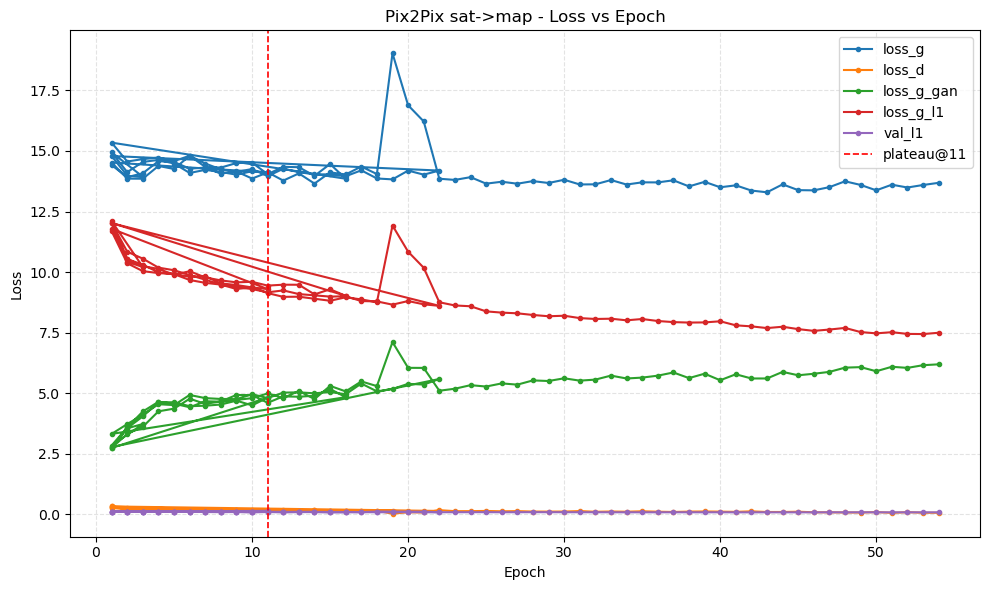

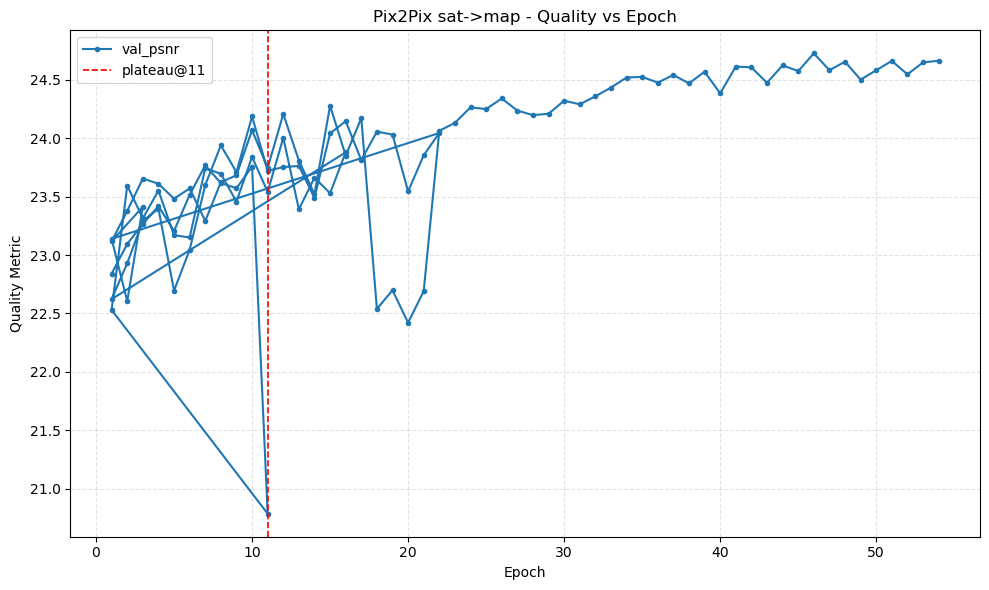

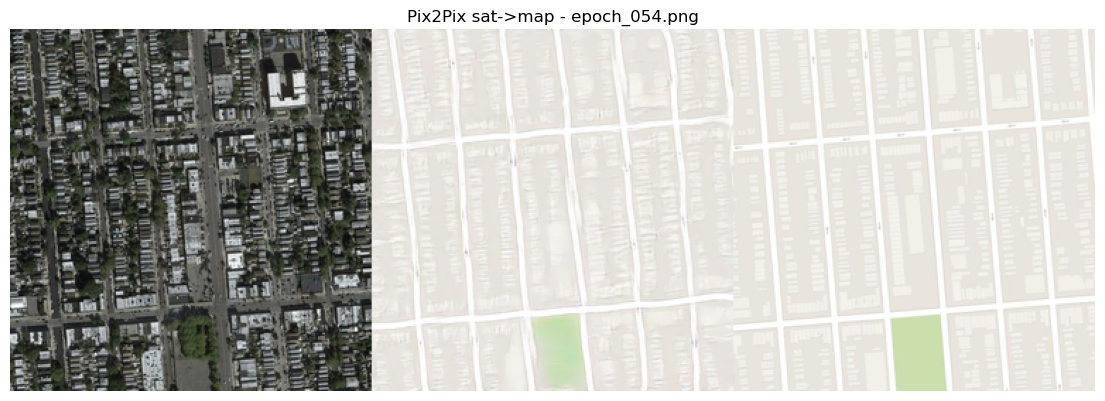

{'log_path': '/home/arderd/tmp/outputs/pix2pix_sat2map/logs/train_log.jsonl',
 'loss_keys': ['loss_g', 'loss_d', 'loss_g_gan', 'loss_g_l1', 'val_l1'],
 'quality_keys': ['val_psnr'],
 'loss_plot_written': True,
 'quality_plot_written': True,
 'plateau': {'metric': 'val_l1',
  'mode': 'min',
  'best_epoch': 10,
  'best_value': 0.08976418254514264,
  'trigger_epoch': 11,
  'patience': 12,
  'min_delta': 0.0005}}

In [7]:
sat2map_plots = build_training_plots(
    sat2map_run["log_path"],
    title_prefix="Pix2Pix sat->map",
    plateau_metric="val_l1",
    plateau_mode="min",
    plateau_patience=EARLY_STOPPING_PATIENCE,
    plateau_min_delta=EARLY_STOPPING_MIN_DELTA,
)
show_latest_sample(sat2map_run["samples_dir"], "Pix2Pix sat->map")
sat2map_plots
